# ドル円 為替レート 15分足

### 一つ上のディレクトリをパスに追加

In [1]:
import sys
path_up = '..'
if not path_up in sys.path:
    sys.path.append(path_up)

### ライブラリをここで一括インポート

In [2]:
import datetime

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import mplfinance as mpf
import numpy as np
import pandas as pd
import yfinance as yf

from funcs.commons import get_name_15min_chart, get_name_15min_chart_now

## yfinance による株価データの取得

In [3]:
code = "USDJPY=X"
symbol = code
ticker = yf.Ticker(symbol)
# 長めにデータを取得しておく
df = ticker.history(period='2d', interval='15m')
# タイムゾーンを日本時間に変換
df.index = df.index.tz_convert('Asia/Tokyo')
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-17 08:00:00+09:00,159.106995,159.160995,159.095993,159.115005,0,0.0,0.0
2026-04-17 08:15:00+09:00,159.115005,159.128998,159.076004,159.108994,0,0.0,0.0
2026-04-17 08:30:00+09:00,159.108994,159.175995,159.108002,159.156998,0,0.0,0.0
2026-04-17 08:45:00+09:00,159.162994,159.227005,159.149002,159.195007,0,0.0,0.0
2026-04-17 09:00:00+09:00,159.205002,159.263000,159.190994,159.218994,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-20 12:30:00+09:00,158.837006,158.858002,158.789993,158.848007,0,0.0,0.0
2026-04-20 12:45:00+09:00,158.854996,158.886993,158.839996,158.878998,0,0.0,0.0
2026-04-20 13:00:00+09:00,158.876999,158.886002,158.839005,158.863998,0,0.0,0.0


## 時間帯を固定

In [4]:
# 現在時刻から、本日の日付を使用する
dt = datetime.datetime.now()
# ザラ場の取引時間に固定する
dt_start = pd.to_datetime(f"{dt.year}-{dt.month}-{dt.day} 09:00:00+09:00")
dt_end = pd.to_datetime(f"{dt.year}-{dt.month}-{dt.day} 15:30:00+09:00")
df0 = df[(dt_start <= df.index) & (df.index <= dt_end)]
dt_first = df0.index[0]
df0

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-20 09:00:00+09:00,159.151001,159.201004,159.121002,159.181000,0,0.0,0.0
2026-04-20 09:15:00+09:00,159.169998,159.182999,159.052994,159.070007,0,0.0,0.0
2026-04-20 09:30:00+09:00,159.067001,159.078003,158.985001,159.009003,0,0.0,0.0
2026-04-20 09:45:00+09:00,159.003998,159.014999,158.888000,158.998001,0,0.0,0.0
2026-04-20 10:00:00+09:00,159.001007,159.016006,158.917999,158.953995,0,0.0,0.0
2026-04-20 10:15:00+09:00,158.955002,159.013000,158.936005,158.996994,0,0.0,0.0
2026-04-20 10:30:00+09:00,158.996994,159.007004,158.828995,158.888000,0,0.0,0.0
2026-04-20 10:45:00+09:00,158.893005,158.895004,158.832993,158.852005,0,0.0,0.0
2026-04-20 11:00:00+09:00,158.850998,158.895996,158.817993,158.858002,0,0.0,0.0


## ローソク足チャート（小さいサイズ）

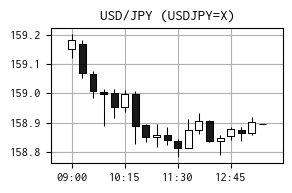

In [5]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['font.size'] = 9

fig, ax = plt.subplots(figsize=(3, 2))
mpf.plot(
    df0,
    type='candle',
    style='default',
    datetime_format='%H:%M',
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.set_ylabel(None)
ax.grid()

if "shortName" in ticker.info:
    ax.set_title(f"{ticker.info['shortName']} ({symbol})")
elif "longName" in ticker.info:
    ax.set_title(f"{ticker.info['longName']} ({symbol})")
else:
    ax.set_title(f"{symbol}")
    
plt.tight_layout()
plt.savefig(get_name_15min_chart(code, dt_first))
plt.show()